# 08 — Definición de Pares A/B y Etiquetas Ground Truth

**Proyecto:** Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad  
**Autor:** Jesús Goenaga Peña  
**Fase:** 2 del pipeline de validación — Definición de pares A/B

---

## ¿Qué hace este notebook?

Para cada una de las 200 imágenes del conjunto de validación, este notebook:

1. **Identifica dos regiones de interés** (A y B) con el máximo contraste posible de disparidad entre ellas.
2. **Asigna la etiqueta ground truth**: cuál de las dos regiones está más cerca de la cámara.
3. **Aleatoriza la asignación A/B**: en el 50% de los casos A es la región cercana y en el otro 50% es la lejana. Esto evita que los participantes aprendan un patrón sistemático.
4. **Guarda las coordenadas** de cada región como bounding box, listo para ser usado por la interfaz experimental del Notebook 10.

## Estrategia técnica

**KITTI:** El mapa de disparidad `disp_occ_0` proporciona profundidad real píxel a píxel. Se divide la imagen en una cuadrícula de celdas, se calcula la disparidad media de cada celda, y se seleccionan las dos celdas con mayor diferencia de disparidad como regiones A y B.

**Ilusiones visuales:** No hay mapa de disparidad real. Se usa una cuadrícula sobre la imagen de color y se seleccionan las dos regiones con mayor contraste de varianza local (proxy de profundidad percibida). La etiqueta ground truth se define como la región de mayor varianza local = perceptualmente más prominente = "más cercana" según la ilusión.

## Resultado

Archivo `pairs_ground_truth.csv` con una fila por imagen y las columnas:
- Coordenadas de la región A y B (bounding box: x, y, ancho, alto)
- Etiqueta ground truth: `'mas_cercano'` o `'mas_lejano'` (referida al objeto A)
- Métricas de disparidad/varianza de cada región

---

## Celda 1 — Montar Drive y definir rutas

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR       = '/content/drive/MyDrive/cognitive-depth-model'
KITTI_DISP_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'kitti',
                              'data_scene_flow', 'training', 'disp_occ_0')
KITTI_LEFT_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'kitti',
                              'data_scene_flow', 'training', 'image_2')
ILLUSION_DIR   = os.path.join(BASE_DIR, 'data', 'raw', 'illusions', 'images')
SPLITS_DIR     = os.path.join(BASE_DIR, 'data', 'splits')
RESULTS_DIR    = os.path.join(BASE_DIR, 'results', 'factorial')
PAIRS_DIR      = os.path.join(BASE_DIR, 'results', 'pairs')
os.makedirs(PAIRS_DIR, exist_ok=True)

# Verificar que el CSV maestro del Notebook 08 existe
CSV_FACTORIAL = os.path.join(SPLITS_DIR, 'factorial_labels.csv')

print('Verificación de rutas:')
print('-' * 55)
for nombre, ruta in [
    ('CSV factorial (NB08)',          CSV_FACTORIAL),
    ('KITTI disparidad (disp_occ_0)', KITTI_DISP_DIR),
    ('KITTI imágenes (image_2)',      KITTI_LEFT_DIR),
    ('Ilusiones (images/)',           ILLUSION_DIR),
    ('Resultados pares',              PAIRS_DIR),
]:
    existe = os.path.exists(ruta)
    print(f'  {"✓" if existe else "✗"}  {nombre}')

print()
print('Si todo está en verde, continúa con la Celda 2.')

Mounted at /content/drive
Verificación de rutas:
-------------------------------------------------------
  ✓  CSV factorial (NB08)
  ✓  KITTI disparidad (disp_occ_0)
  ✓  KITTI imágenes (image_2)
  ✓  Ilusiones (images/)
  ✓  Resultados pares

Si todo está en verde, continúa con la Celda 2.


## Celda 2 — Importar librerías y cargar CSV factorial

In [2]:
import numpy as np
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad de la aleatorización A/B
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Cargar CSV maestro del Notebook 07
df = pd.read_csv(CSV_FACTORIAL)

print(f'CSV factorial cargado: {len(df)} imágenes')
print(f'  KITTI:      {(df["dataset"]=="KITTI").sum()}')
print(f'  Ilusiones:  {(df["dataset"]=="3D_Illusion").sum()}')
print()
print('Columnas disponibles:')
print(df.columns.tolist())
print()
print(df[['imagen_id','dataset','nivel_disparidad','presencia_distractores']].head(5).to_string(index=False))

CSV factorial cargado: 200 imágenes
  KITTI:      100
  Ilusiones:  100

Columnas disponibles:
['imagen_id', 'dataset', 'tipo_tarea', 'tipo_ilusion', 'nivel_disparidad', 'presencia_distractores', 'disparidad_media', 'densidad_bordes', 'varianza_imagen', 'varianza_residual', 'ruta_img_izq', 'ruta_disp']

imagen_id dataset nivel_disparidad presencia_distractores
000000_10   KITTI             alta       con_distractores
000001_10   KITTI             alta       con_distractores
000002_10   KITTI             baja       con_distractores
000003_10   KITTI             baja       con_distractores
000004_10   KITTI             alta       con_distractores


## Celda 3 — Definir funciones de selección de regiones A/B

In [3]:
# Parámetros de la cuadrícula
# Dividimos cada imagen en GRID_ROWS x GRID_COLS celdas
# y seleccionamos las dos con mayor contraste de disparidad
GRID_ROWS = 3
GRID_COLS = 4
MIN_VALID_PIXELS = 50   # Mínimo de píxeles válidos para considerar una celda
MIN_DISP_DIFF    = 2.0  # Diferencia mínima de disparidad entre A y B (en píxeles)


def seleccionar_regiones_kitti(ruta_disp, ruta_img, grid_rows=GRID_ROWS, grid_cols=GRID_COLS):
    """
    Divide el mapa de disparidad KITTI en una cuadrícula y selecciona
    las dos celdas con mayor diferencia de disparidad media.

    Retorna:
        dict con región A, región B, métricas y ground truth.
        None si no es posible calcular (datos insuficientes).

    El bounding box se reporta como (x, y, ancho, alto) en píxeles
    sobre la imagen original (sin redimensionar).
    """
    mapa = cv2.imread(str(ruta_disp), cv2.IMREAD_UNCHANGED)
    img  = cv2.imread(str(ruta_img))
    if mapa is None or img is None:
        return None

    H, W    = mapa.shape
    mapa_f  = mapa.astype(np.float32) / 256.0

    alto_celda  = H // grid_rows
    ancho_celda = W // grid_cols

    celdas = []
    for r in range(grid_rows):
        for c in range(grid_cols):
            y0 = r * alto_celda
            x0 = c * ancho_celda
            y1 = y0 + alto_celda
            x1 = x0 + ancho_celda
            region = mapa_f[y0:y1, x0:x1]
            validos = region[region > 0]
            if len(validos) >= MIN_VALID_PIXELS:
                celdas.append({
                    'fila': r, 'col': c,
                    'x': x0, 'y': y0,
                    'ancho': ancho_celda, 'alto': alto_celda,
                    'disp_media': float(np.mean(validos)),
                    'n_validos': len(validos)
                })

    if len(celdas) < 2:
        return None

    # Encontrar el par de celdas no adyacentes con mayor diferencia de disparidad
    mejor_diff  = -1
    celda_cerca = None
    celda_lejos = None

    for i in range(len(celdas)):
        for j in range(i+1, len(celdas)):
            ci, cj = celdas[i], celdas[j]
            # Evitar celdas adyacentes (mismo row o col contiguo)
            if abs(ci['fila']-cj['fila']) <= 1 and abs(ci['col']-cj['col']) <= 1:
                continue
            diff = abs(ci['disp_media'] - cj['disp_media'])
            if diff > mejor_diff:
                mejor_diff = diff
                if ci['disp_media'] >= cj['disp_media']:
                    celda_cerca, celda_lejos = ci, cj
                else:
                    celda_cerca, celda_lejos = cj, ci

    if celda_cerca is None or mejor_diff < MIN_DISP_DIFF:
        # Fallback: usar las dos celdas con mayor y menor disparidad sin restricción adyacencia
        celdas_sorted = sorted(celdas, key=lambda x: x['disp_media'])
        celda_lejos   = celdas_sorted[0]
        celda_cerca   = celdas_sorted[-1]
        mejor_diff    = celda_cerca['disp_media'] - celda_lejos['disp_media']

    return {
        'celda_cerca':  celda_cerca,
        'celda_lejos':  celda_lejos,
        'diff_disparidad': mejor_diff,
        'H': H, 'W': W
    }


def seleccionar_regiones_ilusion(ruta_img, grid_rows=GRID_ROWS, grid_cols=GRID_COLS):
    """
    Para ilusiones visuales (sin mapa de disparidad real):
    Usa la varianza local de intensidad como proxy de profundidad percibida.
    Mayor varianza local = región perceptualmente más activa = percibida como más cercana.

    Retorna el mismo formato que seleccionar_regiones_kitti.
    """
    img = cv2.imread(str(ruta_img), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    H, W        = img.shape
    alto_celda  = H // grid_rows
    ancho_celda = W // grid_cols

    celdas = []
    for r in range(grid_rows):
        for c in range(grid_cols):
            y0 = r * alto_celda
            x0 = c * ancho_celda
            region = img[y0:y0+alto_celda, x0:x0+ancho_celda].astype(np.float32)
            celdas.append({
                'fila': r, 'col': c,
                'x': x0, 'y': y0,
                'ancho': ancho_celda, 'alto': alto_celda,
                'disp_media': float(np.var(region)),  # varianza como proxy
                'n_validos': region.size
            })

    if len(celdas) < 2:
        return None

    mejor_diff  = -1
    celda_cerca = None
    celda_lejos = None

    for i in range(len(celdas)):
        for j in range(i+1, len(celdas)):
            ci, cj = celdas[i], celdas[j]
            if abs(ci['fila']-cj['fila']) <= 1 and abs(ci['col']-cj['col']) <= 1:
                continue
            diff = abs(ci['disp_media'] - cj['disp_media'])
            if diff > mejor_diff:
                mejor_diff = diff
                if ci['disp_media'] >= cj['disp_media']:
                    celda_cerca, celda_lejos = ci, cj
                else:
                    celda_cerca, celda_lejos = cj, ci

    if celda_cerca is None:
        celdas_sorted = sorted(celdas, key=lambda x: x['disp_media'])
        celda_lejos   = celdas_sorted[0]
        celda_cerca   = celdas_sorted[-1]
        mejor_diff    = celda_cerca['disp_media'] - celda_lejos['disp_media']

    return {
        'celda_cerca':  celda_cerca,
        'celda_lejos':  celda_lejos,
        'diff_disparidad': mejor_diff,
        'H': H, 'W': W
    }


print('Funciones definidas correctamente.')
print(f'Cuadrícula: {GRID_ROWS} filas × {GRID_COLS} columnas = {GRID_ROWS*GRID_COLS} celdas por imagen')

Funciones definidas correctamente.
Cuadrícula: 3 filas × 4 columnas = 12 celdas por imagen


## Celda 4 — Procesar todas las imágenes y asignar pares A/B

In [4]:
print('Procesando imágenes y definiendo pares A/B...')
print('Tiempo estimado: 2-3 minutos.\n')

# Lista de índices para aleatorizar asignación A/B
# La mitad de las imágenes tendrán A=cercana, la otra mitad A=lejana
indices = list(range(len(df)))
random.shuffle(indices)
a_es_cercano = set(indices[:len(indices)//2])  # 50% A=cercano

registros = []
errores   = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Pares A/B'):

    ruta_img  = row['ruta_img_izq'] if pd.notna(row['ruta_img_izq']) else ''
    ruta_disp = row['ruta_disp']    if pd.notna(row['ruta_disp'])    else ''

    # Seleccionar regiones según el dataset
    resultado = None
    if row['dataset'] == 'KITTI' and ruta_disp and os.path.exists(ruta_disp):
        resultado = seleccionar_regiones_kitti(ruta_disp, ruta_img)
    elif ruta_img and os.path.exists(ruta_img):
        resultado = seleccionar_regiones_ilusion(ruta_img)

    if resultado is None:
        errores.append(row['imagen_id'])
        registros.append({
            'imagen_id': row['imagen_id'],
            'dataset':   row['dataset'],
            'tipo_tarea': row['tipo_tarea'],
            'nivel_disparidad': row['nivel_disparidad'],
            'presencia_distractores': row['presencia_distractores'],
            'error': 'no_procesada'
        })
        continue

    celda_cerca = resultado['celda_cerca']
    celda_lejos = resultado['celda_lejos']

    # Aleatorizar: ¿A es la región cercana o la lejana?
    if idx in a_es_cercano:
        region_A   = celda_cerca
        region_B   = celda_lejos
        gt_label   = 'mas_cercano'   # A está más cerca
    else:
        region_A   = celda_lejos
        region_B   = celda_cerca
        gt_label   = 'mas_lejano'    # A está más lejos

    registros.append({
        # Identificación
        'imagen_id':                row['imagen_id'],
        'dataset':                  row['dataset'],
        'tipo_tarea':               row['tipo_tarea'],
        'tipo_ilusion':             row.get('tipo_ilusion', ''),
        'nivel_disparidad':         row['nivel_disparidad'],
        'presencia_distractores':   row['presencia_distractores'],
        'ruta_img_izq':             ruta_img,
        'ruta_disp':                ruta_disp,
        # Región A
        'A_x':                      region_A['x'],
        'A_y':                      region_A['y'],
        'A_ancho':                  region_A['ancho'],
        'A_alto':                   region_A['alto'],
        'A_metrica':                region_A['disp_media'],
        # Región B
        'B_x':                      region_B['x'],
        'B_y':                      region_B['y'],
        'B_ancho':                  region_B['ancho'],
        'B_alto':                   region_B['alto'],
        'B_metrica':                region_B['disp_media'],
        # Ground truth y métricas
        'ground_truth':             gt_label,
        'diferencia_metrica':       resultado['diff_disparidad'],
        'img_H':                    resultado['H'],
        'img_W':                    resultado['W'],
        'error':                    ''
    })

df_pairs = pd.DataFrame(registros)

print(f'\nTotal procesadas:      {len(df_pairs)}')
print(f'Con pares A/B válidos: {(df_pairs["error"]=="").sum()}')
print(f'Con error:             {len(errores)}')
print()
print('Distribución de ground truth (A más cercano vs más lejano):')
print(df_pairs['ground_truth'].value_counts().to_string())
print()
print('Balance de ground truth por tipo de tarea:')
print(df_pairs.groupby(['tipo_tarea','ground_truth']).size().to_string())

Procesando imágenes y definiendo pares A/B...
Tiempo estimado: 2-3 minutos.



Pares A/B: 100%|██████████| 200/200 [04:10<00:00,  1.25s/it]


Total procesadas:      200
Con pares A/B válidos: 200
Con error:             0

Distribución de ground truth (A más cercano vs más lejano):
ground_truth
mas_cercano    100
mas_lejano     100

Balance de ground truth por tipo de tarea:
tipo_tarea                  ground_truth
discriminacion_profundidad  mas_cercano     45
                            mas_lejano      55
ilusion_visual              mas_cercano     55
                            mas_lejano      45


## Celda 5 — Visualización de ejemplos de pares A/B

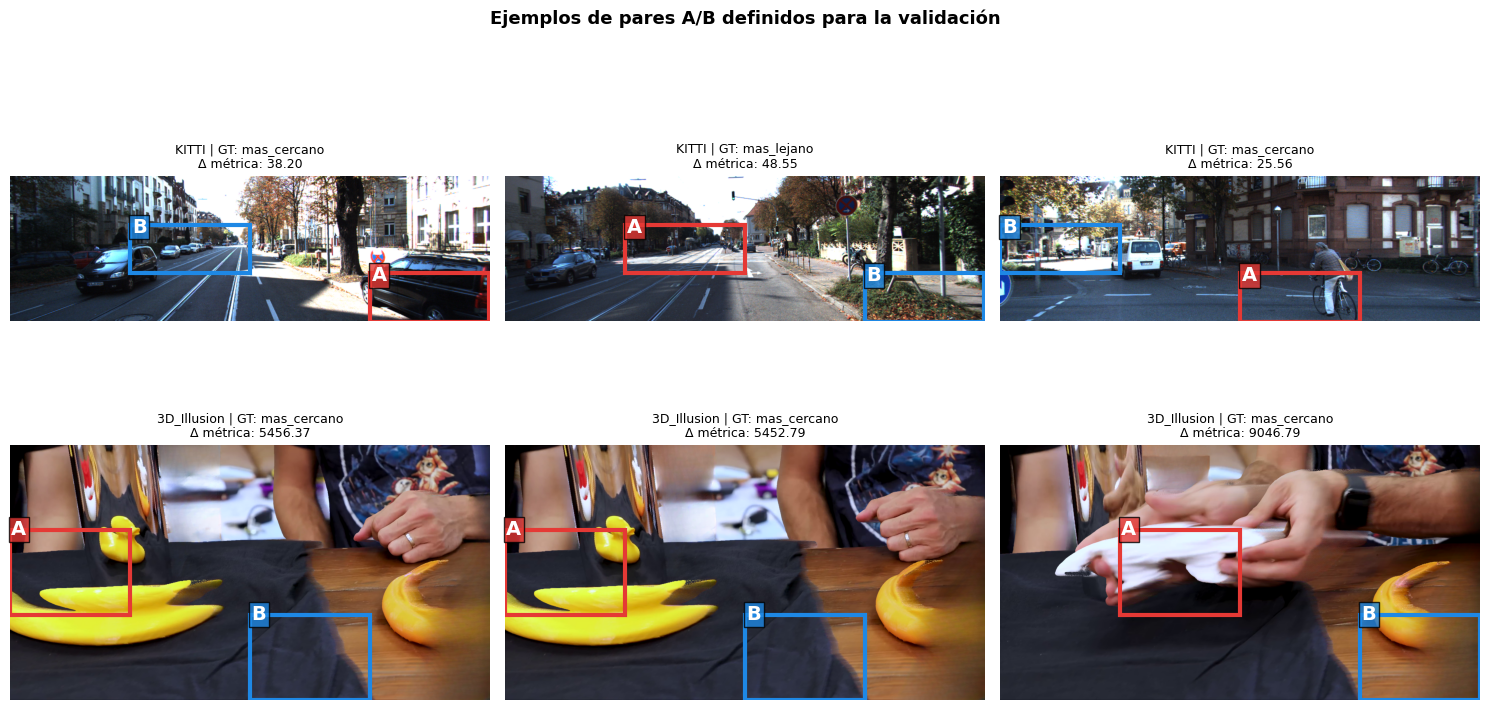

Figura guardada en: /content/drive/MyDrive/cognitive-depth-model/results/pairs/ejemplos_pares_AB.png


In [5]:
# Mostrar 6 ejemplos: 3 KITTI y 3 Ilusiones
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Ejemplos de pares A/B definidos para la validación',
             fontsize=13, fontweight='bold')

datasets = ['KITTI', '3D_Illusion']
colores  = {'A': '#E53935', 'B': '#1E88E5'}  # A rojo, B azul

for fila, dataset in enumerate(datasets):
    muestras = df_pairs[
        (df_pairs['dataset'] == dataset) & (df_pairs['error'] == '')
    ].head(3)

    for col, (_, row) in enumerate(muestras.iterrows()):
        ax = axes[fila, col]

        ruta_img = row['ruta_img_izq']
        if not ruta_img or not os.path.exists(ruta_img):
            ax.text(0.5, 0.5, 'Imagen no disponible',
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        img = cv2.imread(ruta_img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        # Dibujar bounding box A
        rect_A = patches.Rectangle(
            (row['A_x'], row['A_y']), row['A_ancho'], row['A_alto'],
            linewidth=3, edgecolor=colores['A'], facecolor='none'
        )
        ax.add_patch(rect_A)
        ax.text(row['A_x']+5, row['A_y']+20, 'A',
                color='white', fontsize=14, fontweight='bold',
                bbox=dict(facecolor=colores['A'], alpha=0.8, pad=2))

        # Dibujar bounding box B
        rect_B = patches.Rectangle(
            (row['B_x'], row['B_y']), row['B_ancho'], row['B_alto'],
            linewidth=3, edgecolor=colores['B'], facecolor='none'
        )
        ax.add_patch(rect_B)
        ax.text(row['B_x']+5, row['B_y']+20, 'B',
                color='white', fontsize=14, fontweight='bold',
                bbox=dict(facecolor=colores['B'], alpha=0.8, pad=2))

        gt_texto = '¿A más cercano?' if row['ground_truth']=='mas_cercano' else '¿A más lejano?'
        ax.set_title(f'{dataset} | GT: {row["ground_truth"]}\nΔ métrica: {row["diferencia_metrica"]:.2f}',
                     fontsize=9)
        ax.axis('off')

plt.tight_layout()
ruta_fig = os.path.join(PAIRS_DIR, 'ejemplos_pares_AB.png')
plt.savefig(ruta_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {ruta_fig}')

## Celda 6 — Verificar calidad de los pares: distribución de diferencias

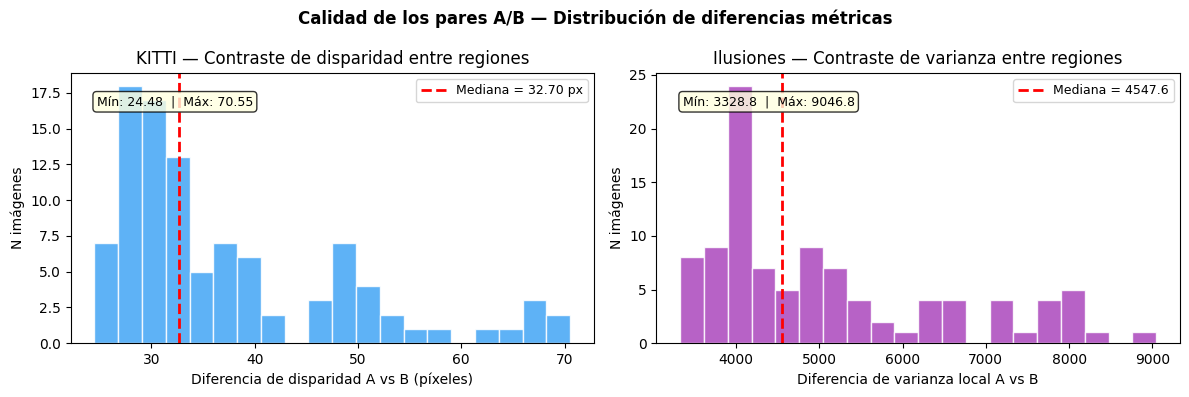

Figura guardada en: /content/drive/MyDrive/cognitive-depth-model/results/pairs/distribucion_diferencias_AB.png

Interpretación:
  Mayor diferencia = par A/B más distinguible = tarea más fácil
  Menor diferencia = par A/B más ambiguo = tarea más difícil
  Ambos rangos son necesarios para evaluar el modelo en distintos niveles de dificultad.


In [6]:
df_validos = df_pairs[df_pairs['error'] == ''].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Calidad de los pares A/B — Distribución de diferencias métricas',
             fontsize=12, fontweight='bold')

# KITTI: diferencia de disparidad entre A y B
ax = axes[0]
diff_k = df_validos.loc[df_validos['dataset']=='KITTI', 'diferencia_metrica']
ax.hist(diff_k, bins=20, color='#42A5F5', edgecolor='white', alpha=0.85)
ax.axvline(diff_k.median(), color='red', lw=2, ls='--',
           label=f'Mediana = {diff_k.median():.2f} px')
ax.set_xlabel('Diferencia de disparidad A vs B (píxeles)')
ax.set_ylabel('N imágenes')
ax.set_title('KITTI — Contraste de disparidad entre regiones')
ax.legend(fontsize=9)
ax.text(0.05, 0.88, f'Mín: {diff_k.min():.2f}  |  Máx: {diff_k.max():.2f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Ilusiones: diferencia de varianza entre A y B
ax = axes[1]
diff_i = df_validos.loc[df_validos['dataset']=='3D_Illusion', 'diferencia_metrica']
ax.hist(diff_i, bins=20, color='#AB47BC', edgecolor='white', alpha=0.85)
ax.axvline(diff_i.median(), color='red', lw=2, ls='--',
           label=f'Mediana = {diff_i.median():.1f}')
ax.set_xlabel('Diferencia de varianza local A vs B')
ax.set_ylabel('N imágenes')
ax.set_title('Ilusiones — Contraste de varianza entre regiones')
ax.legend(fontsize=9)
ax.text(0.05, 0.88, f'Mín: {diff_i.min():.1f}  |  Máx: {diff_i.max():.1f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
ruta_fig2 = os.path.join(PAIRS_DIR, 'distribucion_diferencias_AB.png')
plt.savefig(ruta_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {ruta_fig2}')
print()
print('Interpretación:')
print('  Mayor diferencia = par A/B más distinguible = tarea más fácil')
print('  Menor diferencia = par A/B más ambiguo = tarea más difícil')
print('  Ambos rangos son necesarios para evaluar el modelo en distintos niveles de dificultad.')

## Celda 7 — Guardar CSV de pares ground truth

In [7]:
ruta_csv_pairs  = os.path.join(PAIRS_DIR,  'pairs_ground_truth.csv')
ruta_csv_splits = os.path.join(SPLITS_DIR, 'pairs_ground_truth.csv')

df_pairs.to_csv(ruta_csv_pairs,  index=False)
df_pairs.to_csv(ruta_csv_splits, index=False)

print('✓ CSV de pares guardado.')
print(f'  → {ruta_csv_pairs}')
print(f'  → {ruta_csv_splits}')
print(f'\nTotal registros: {len(df_pairs)}')
print()
print('Vista previa (columnas clave):')
cols_preview = ['imagen_id','dataset','ground_truth',
                'A_x','A_y','A_ancho','A_alto','A_metrica',
                'B_x','B_y','B_ancho','B_alto','B_metrica']
print(df_pairs[cols_preview].head(6).to_string(index=False))

✓ CSV de pares guardado.
  → /content/drive/MyDrive/cognitive-depth-model/results/pairs/pairs_ground_truth.csv
  → /content/drive/MyDrive/cognitive-depth-model/data/splits/pairs_ground_truth.csv

Total registros: 200

Vista previa (columnas clave):
imagen_id dataset ground_truth  A_x  A_y  A_ancho  A_alto  A_metrica  B_x  B_y  B_ancho  B_alto  B_metrica
000000_10   KITTI  mas_cercano  930  250      310     125  57.997101  310  125      310     125  19.799799
000001_10   KITTI   mas_lejano  310  125      310     125  13.941279  930  250      310     125  62.490944
000002_10   KITTI  mas_cercano  620  250      310     125  42.356701    0  125      310     125  16.796909
000003_10   KITTI  mas_cercano  930    0      310     125  66.660225    0  125      310     125  15.712785
000004_10   KITTI   mas_lejano  310  125      310     125  21.401978  930  250      310     125  79.573982
000005_10   KITTI  mas_cercano  930  250      310     125  86.538841  310  125      310     125  20.360903


## Celda 8 — Resumen final

In [8]:
df_v = df_pairs[df_pairs['error'] == '']

print('=' * 65)
print('RESUMEN FINAL — PARES A/B Y GROUND TRUTH')
print('=' * 65)
print(f'Total imágenes procesadas:      {len(df_pairs)}')
print(f'  Con par A/B válido:           {len(df_v)}')
print(f'  Con error (sin procesar):     {len(errores)}')
print()
print('Ground truth global:')
print(f'  A es más cercano: {(df_v["ground_truth"]=="mas_cercano").sum()}')
print(f'  A es más lejano:  {(df_v["ground_truth"]=="mas_lejano").sum()}')
print()
print('Ground truth por tipo de tarea:')
print(df_v.groupby(['tipo_tarea','ground_truth']).size().to_string())
print()
print('Ground truth por condición factorial:')
print(df_v.groupby(['nivel_disparidad','presencia_distractores','ground_truth']).size().to_string())
print()
print('Archivos generados:')
print(f'  1. results/pairs/pairs_ground_truth.csv')
print(f'  2. data/splits/pairs_ground_truth.csv')
print(f'  3. results/pairs/ejemplos_pares_AB.png')
print(f'  4. results/pairs/distribucion_diferencias_AB.png')
print()
print('Próximo paso → Notebook 10: Selección balanceada del set de validación con humanos.')

RESUMEN FINAL — PARES A/B Y GROUND TRUTH
Total imágenes procesadas:      200
  Con par A/B válido:           200
  Con error (sin procesar):     0

Ground truth global:
  A es más cercano: 100
  A es más lejano:  100

Ground truth por tipo de tarea:
tipo_tarea                  ground_truth
discriminacion_profundidad  mas_cercano     45
                            mas_lejano      55
ilusion_visual              mas_cercano     55
                            mas_lejano      45

Ground truth por condición factorial:
nivel_disparidad  presencia_distractores  ground_truth
alta              con_distractores        mas_cercano     31
                                          mas_lejano      24
                  sin_distractores        mas_cercano     20
                                          mas_lejano      25
baja              con_distractores        mas_cercano     26
                                          mas_lejano      19
                  sin_distractores        mas_cercano     23
